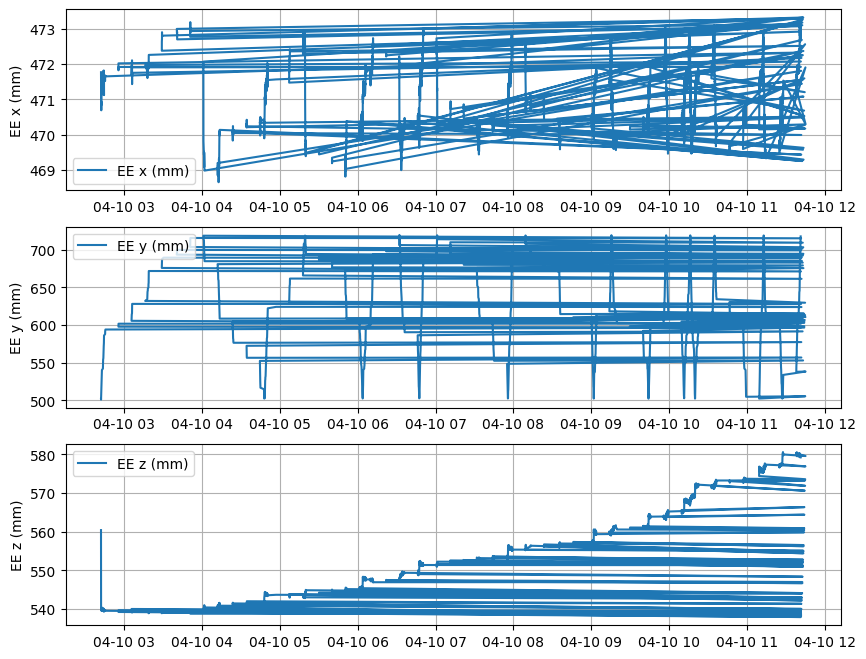

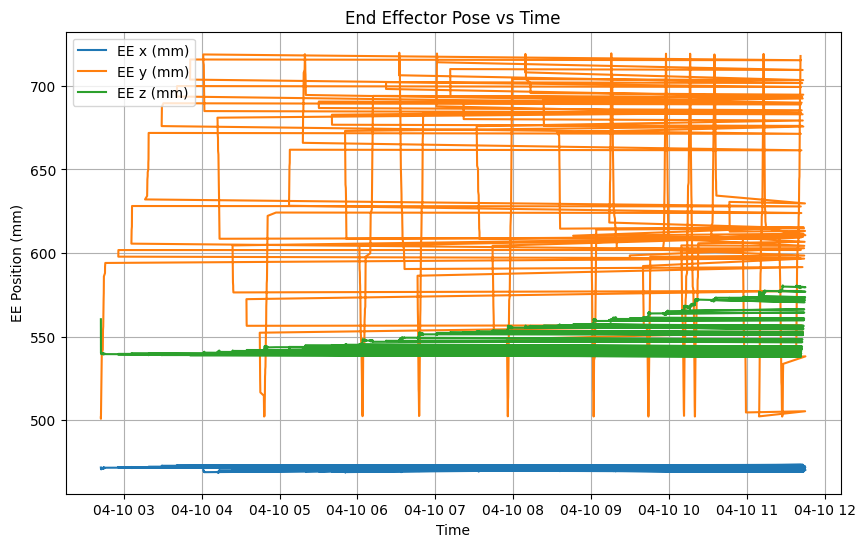

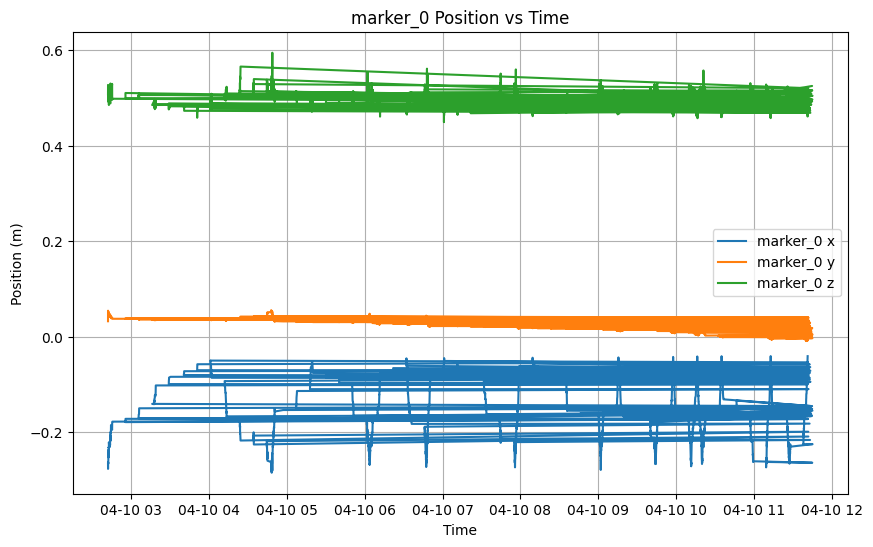

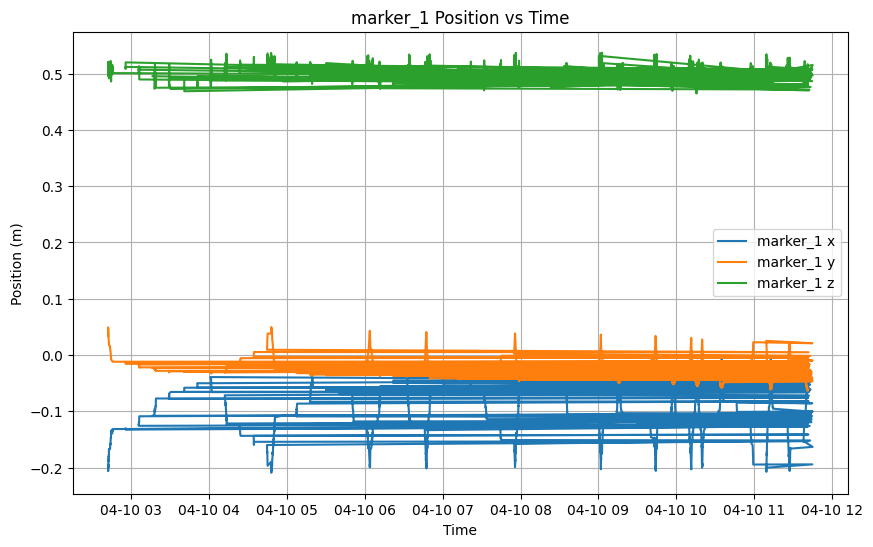

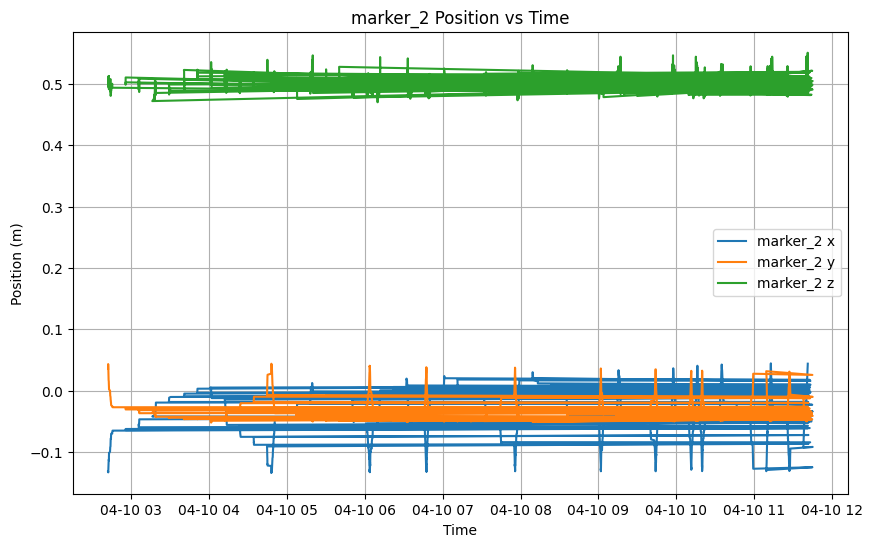

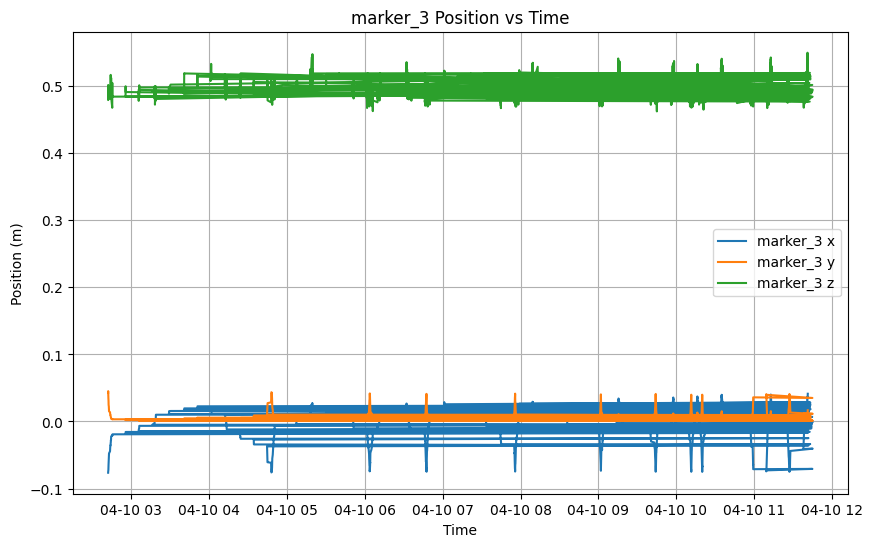

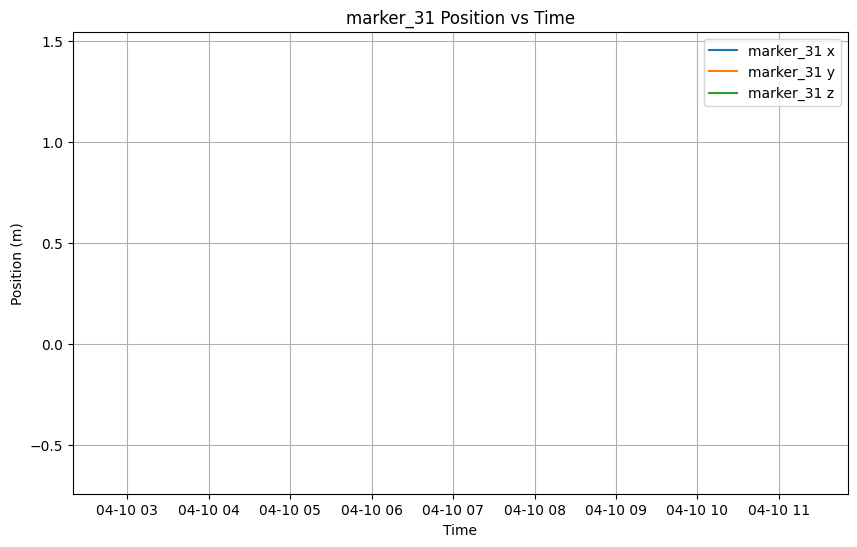

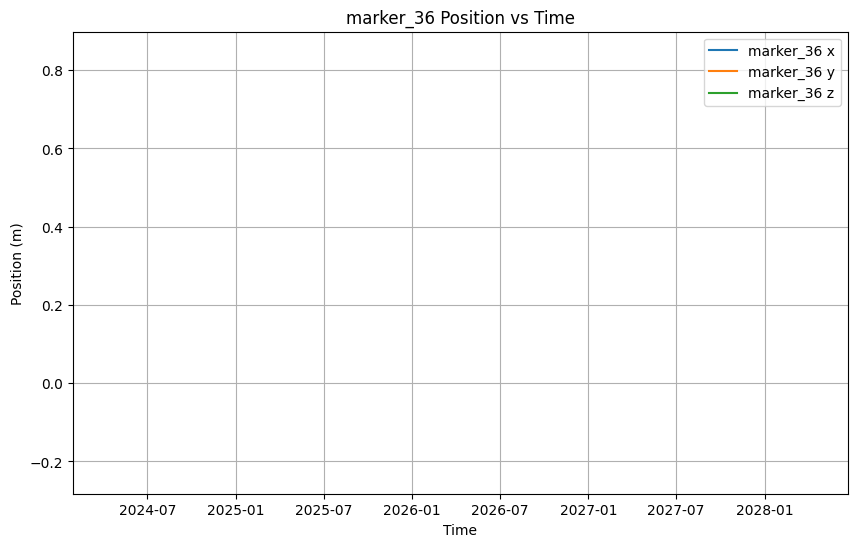

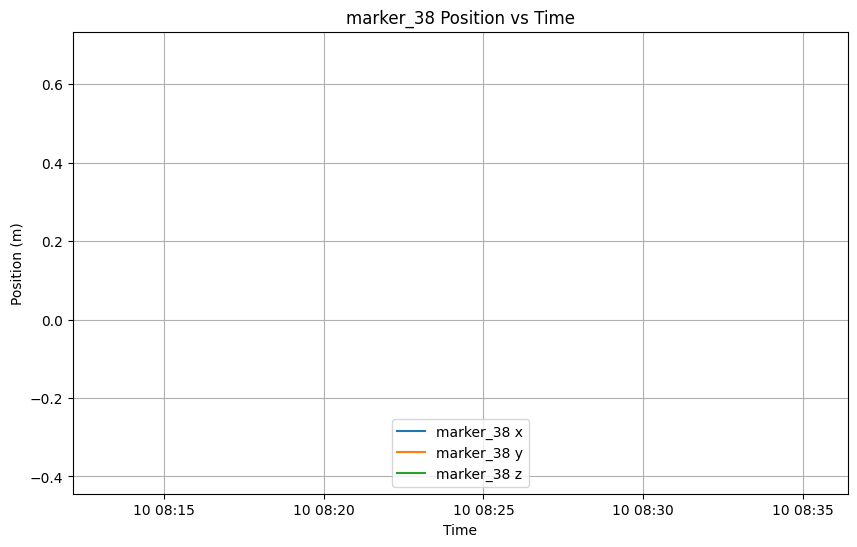

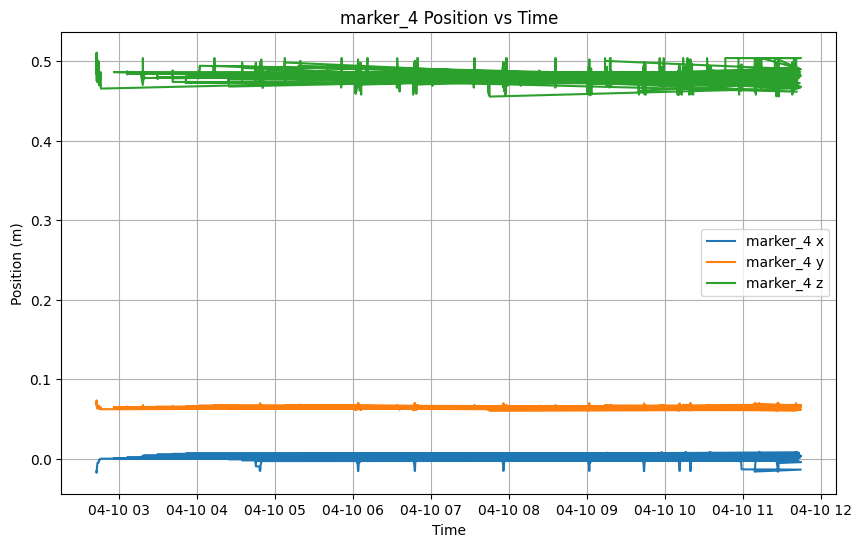

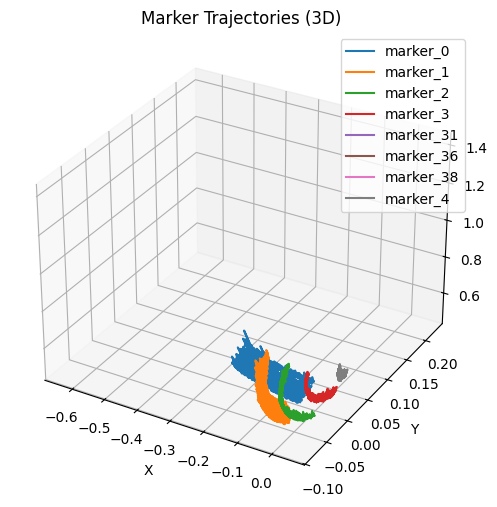

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

# =========================
# Load file
# =========================
# file_path = "DLO_slinky_test_data_20260407_212931.json"  # change if needed
file_path = "DLO_brizier_2d_rect_2332pts_v1.json"  # change if needed

data = []
with open(file_path, "r") as f:
    for line in f:
        try:
            data.append(json.loads(line))
        except:
            continue  # skip malformed lines


# =========================
# Parse timestamps
# =========================
timestamps = []
for d in data:
    try:
        timestamps.append(datetime.fromisoformat(d["timestamp"]))
    except:
        timestamps.append(None)

timestamps = np.array(timestamps)


# =========================
# Extract EE pose
# =========================
ee_x, ee_y, ee_z = [], [], []

for d in data:
    if "ee_pose" in d:
        ee_x.append(d["ee_pose"].get("x_mm", np.nan))
        ee_y.append(d["ee_pose"].get("y_mm", np.nan))
        ee_z.append(d["ee_pose"].get("z_mm", np.nan))
    else:
        ee_x.append(np.nan)
        ee_y.append(np.nan)
        ee_z.append(np.nan)

ee_x = np.array(ee_x)
ee_y = np.array(ee_y)
ee_z = np.array(ee_z)


# =========================
# Extract marker data
# =========================
marker_names = set()
for d in data:
    if "markers" in d:
        marker_names.update(d["markers"].keys())

marker_names = sorted(list(marker_names))

marker_data = {
    name: {"x": [], "y": [], "z": []}
    for name in marker_names
}

for d in data:
    markers = d.get("markers", {})
    for name in marker_names:
        if name in markers:
            marker_data[name]["x"].append(markers[name].get("x", np.nan))
            marker_data[name]["y"].append(markers[name].get("y", np.nan))
            marker_data[name]["z"].append(markers[name].get("z", np.nan))
        else:
            # missing marker → NaN (breaks line in plot)
            marker_data[name]["x"].append(np.nan)
            marker_data[name]["y"].append(np.nan)
            marker_data[name]["z"].append(np.nan)

# convert to numpy
for name in marker_names:
    for coord in ["x", "y", "z"]:
        marker_data[name][coord] = np.array(marker_data[name][coord])


# =========================
# Plot EE pose
# =========================
# plot x, y, z in separate subplots
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 8))
ax1.plot(timestamps, ee_x, label="EE x (mm)")
ax1.set_ylabel("EE x (mm)")
ax1.legend()
ax1.grid(True)

ax2.plot(timestamps, ee_y, label="EE y (mm)")
ax2.set_ylabel("EE y (mm)")
ax2.legend()
ax2.grid(True)

ax3.plot(timestamps, ee_z, label="EE z (mm)")
ax3.set_ylabel("EE z (mm)")
ax3.legend()
ax3.grid(True)

plt.figure(figsize=(10, 6))
plt.plot(timestamps, ee_x, label="EE x (mm)")
plt.plot(timestamps, ee_y, label="EE y (mm)")
plt.plot(timestamps, ee_z, label="EE z (mm)")
plt.xlabel("Time")
plt.ylabel("EE Position (mm)")
plt.title("End Effector Pose vs Time")
plt.legend()
plt.grid(True)


# =========================
# Plot markers (separate figures)
# =========================
for name in marker_names:
    plt.figure(figsize=(10, 6))
    plt.plot(timestamps, marker_data[name]["x"], label=f"{name} x")
    plt.plot(timestamps, marker_data[name]["y"], label=f"{name} y")
    plt.plot(timestamps, marker_data[name]["z"], label=f"{name} z")

    plt.xlabel("Time")
    plt.ylabel("Position (m)")
    plt.title(f"{name} Position vs Time")
    plt.legend()
    plt.grid(True)


# =========================
# Optional: 3D trajectory plot
# =========================
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

for name in marker_names:
    ax.plot(
        marker_data[name]["x"],
        marker_data[name]["y"],
        marker_data[name]["z"],
        label=name
    )

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title("Marker Trajectories (3D)")
ax.legend()

plt.show()

In [2]:
import json
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

data = []
with open(file_path, "r") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        try:
            data.append(json.loads(line))
        except json.JSONDecodeError:
            continue

print(f"Loaded {len(data)} samples")

# =========================
# Parse timestamps
# =========================
timestamps = []
for d in data:
    try:
        timestamps.append(datetime.fromisoformat(d["timestamp"]))
    except:
        timestamps.append(None)
timestamps = np.array(timestamps)

# =========================
# Extract end-effector raw pose
# =========================
ee_x_raw, ee_y_raw, ee_z_raw = [], [], []

for d in data:
    ee = d.get("ee_pose", {})
    ee_x_raw.append(ee.get("x_mm", np.nan))
    ee_y_raw.append(ee.get("y_mm", np.nan))
    ee_z_raw.append(ee.get("z_mm", np.nan))

ee_x_raw = np.array(ee_x_raw, dtype=float)
ee_y_raw = np.array(ee_y_raw, dtype=float)
ee_z_raw = np.array(ee_z_raw, dtype=float)

# =========================
# Extract marker data
# =========================
marker_names = set()
for d in data:
    marker_names.update(d.get("markers", {}).keys())
marker_names = sorted(marker_names)

marker_data = {
    name: {"x": [], "y": [], "z": []}
    for name in marker_names
}

for d in data:
    markers = d.get("markers", {})
    for name in marker_names:
        if name in markers:
            marker_data[name]["x"].append(markers[name].get("x", np.nan))
            marker_data[name]["y"].append(markers[name].get("y", np.nan))
            marker_data[name]["z"].append(markers[name].get("z", np.nan))
        else:
            marker_data[name]["x"].append(np.nan)
            marker_data[name]["y"].append(np.nan)
            marker_data[name]["z"].append(np.nan)

for name in marker_names:
    for c in ["x", "y", "z"]:
        marker_data[name][c] = np.array(marker_data[name][c], dtype=float)



Loaded 2332 samples


In [3]:
# =========================
# Define origin from marker_4 mean position
# =========================
ref_name = "marker_4"

origin_x = np.nanmean(marker_data[ref_name]["x"])
origin_y = np.nanmean(marker_data[ref_name]["y"])
origin_z = np.nanmean(marker_data[ref_name]["z"])

print("Origin from marker_4 mean:")
print("x0 =", origin_x)
print("y0 =", origin_y)
print("z0 =", origin_z)

# =========================
# Remove global offset from all markers
# =========================
marker_data_centered = {}

for name in marker_names:
    marker_data_centered[name] = {
        "x": marker_data[name]["x"] - origin_x,
        "y": marker_data[name]["y"] - origin_y,
        "z": marker_data[name]["z"] - origin_z,
    }
    


Origin from marker_4 mean:
x0 = 0.0007803438364001456
y0 = 0.06485704630091334
z0 = 0.4803184081603479


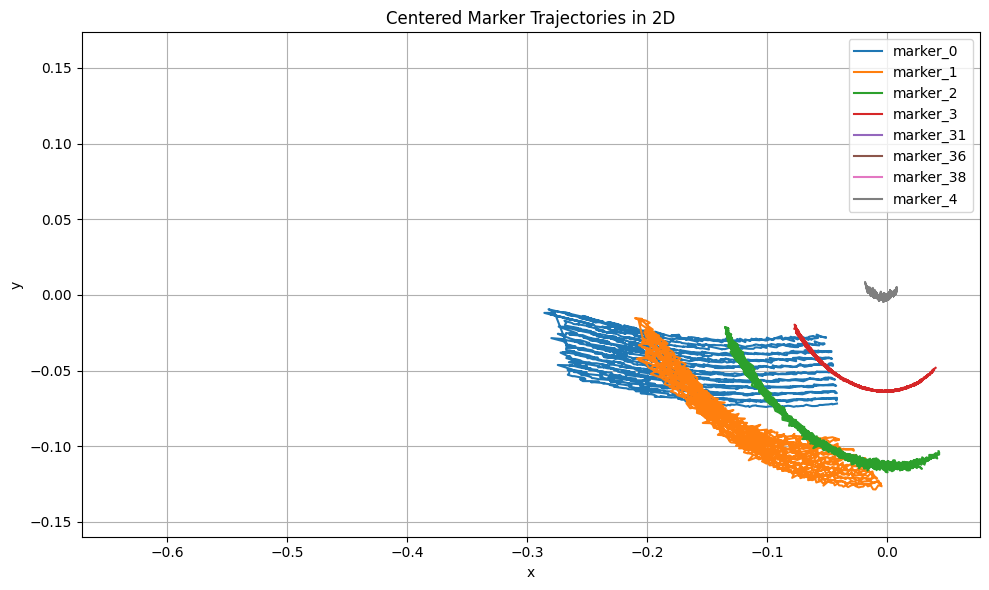

In [4]:
# plot the centered marker trajectories in 2D (x vs y)
plt.figure(figsize=(10, 6))
for name in marker_names:
    plt.plot(marker_data_centered[name]["x"], marker_data_centered[name]["y"], label=name)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Centered Marker Trajectories in 2D")
plt.legend()
plt.grid(True)
plt.tight_layout()

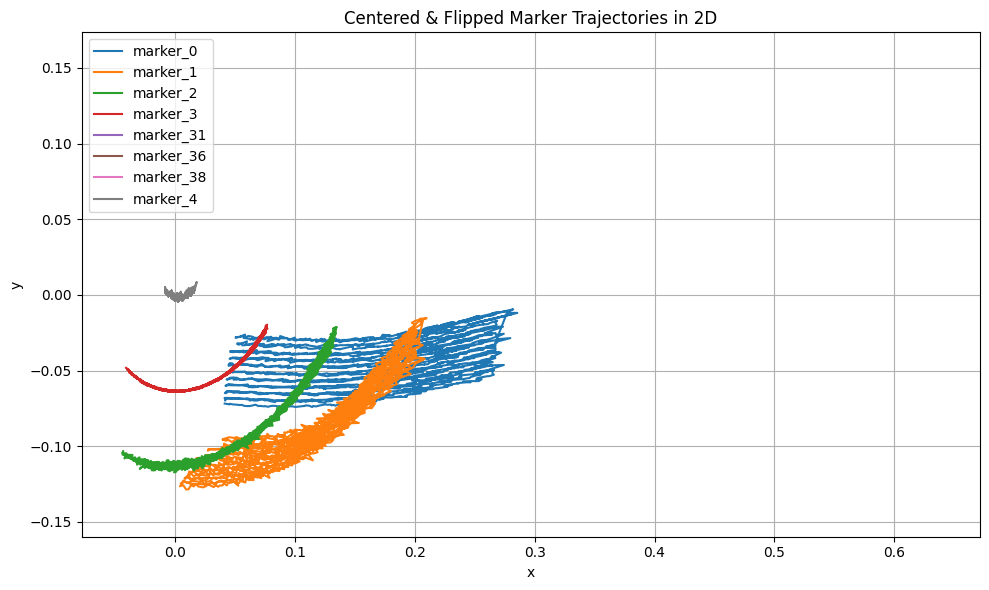

In [5]:
# flip the x axis to match the expected orientation (if needed)
for name in marker_names:
    marker_data_centered[name]["x"] = -marker_data_centered[name]["x"] 
# plot the flipped trajectories
plt.figure(figsize=(10, 6))
for name in marker_names:
    plt.plot(marker_data_centered[name]["x"], marker_data_centered[name]["y"], label=name)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Centered & Flipped Marker Trajectories in 2D")
plt.legend()
plt.grid(True)
plt.tight_layout()

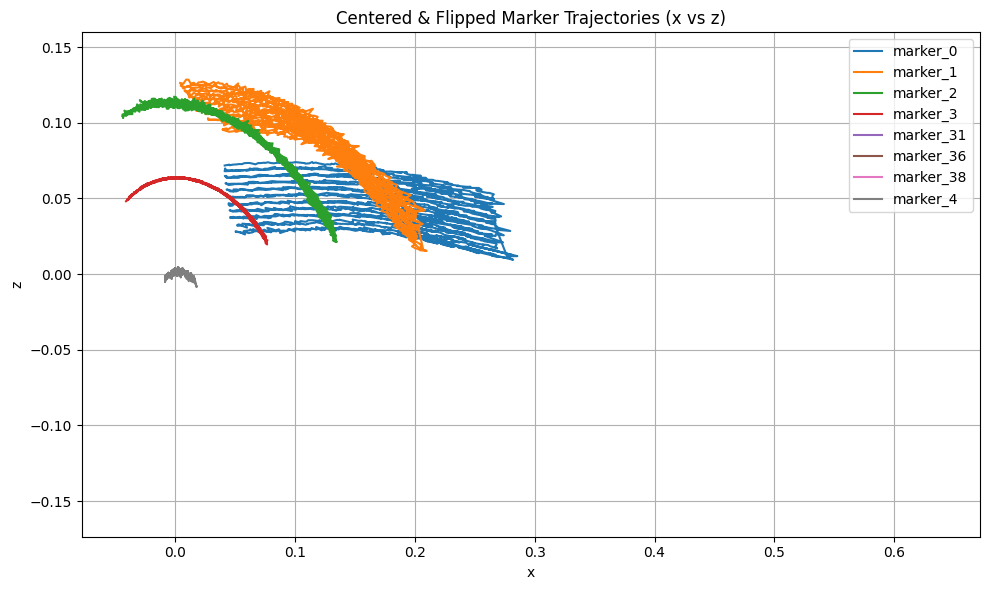

In [6]:
# make -y axis to z axis to match the expected orientation (if needed)
for name in marker_names:
    marker_data_centered[name]["z"] = -marker_data_centered[name]["y"] 
    marker_data_centered[name]["y"] = marker_data_centered[name]["z"]
# plot the final trajectories
plt.figure(figsize=(10, 6))
for name in marker_names:
    plt.plot(marker_data_centered[name]["x"], marker_data_centered[name]["z"], label=name)
plt.xlabel("x")
plt.ylabel("z")
plt.title("Centered & Flipped Marker Trajectories (x vs z)")
plt.legend()
plt.grid(True)
plt.tight_layout()

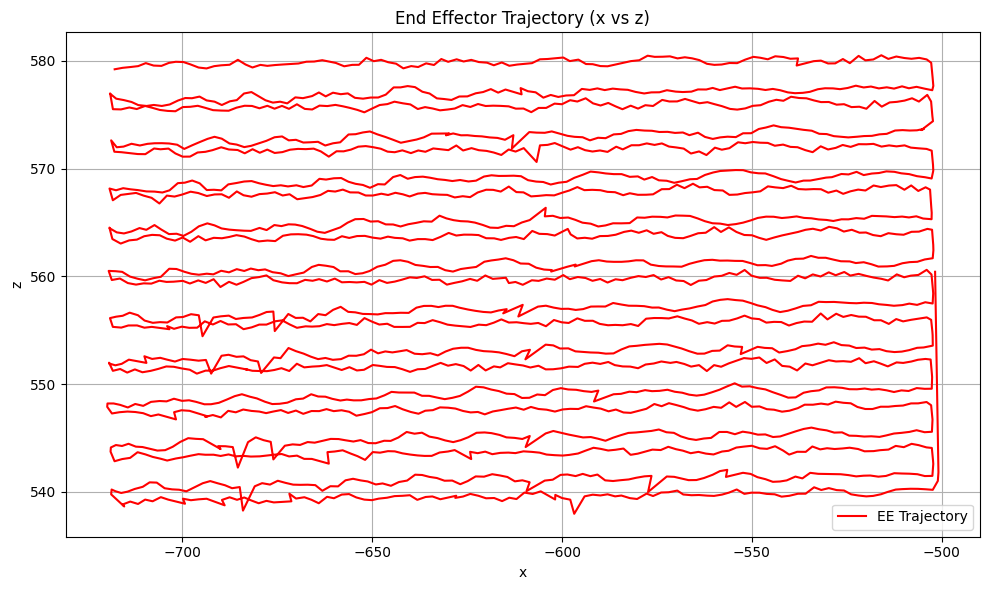

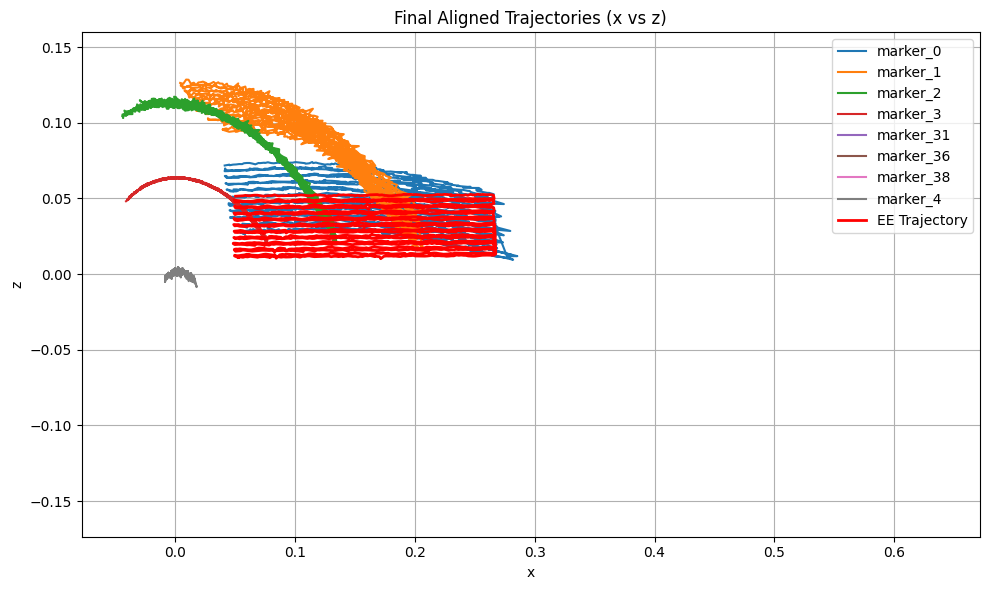

In [7]:
# flip end effector y and make it x to match the expected orientation (if needed)
ee_x = -ee_y_raw
ee_z = ee_z_raw
ee_y = ee_x_raw

# and plot the EE trajectory
plt.figure(figsize=(10, 6))
plt.plot(ee_x, ee_z, label="EE Trajectory", color="red")
plt.xlabel("x")
plt.ylabel("z")
plt.title("End Effector Trajectory (x vs z)")
plt.legend()
plt.grid(True)
plt.tight_layout()

# convert EE trajectory to m from mm
ee_x = ee_x / 1000.0
ee_y = ee_y / 1000.0
ee_z = ee_z / 1000.0   


# now move the first point of ee_trajectory to the first point of (transformed) marker_0 trajectory to roughly align them (if needed)
ee_x = ee_x - ee_x[0] + marker_data_centered["marker_0"]["x"][0]
ee_y = ee_y - ee_y[0] + marker_data_centered["marker_0"]["y"][0]
ee_z = ee_z - ee_z[0] + marker_data_centered["marker_0"]["z"][0]


# plot the final aligned EE trajectory with marker trajectories
plt.figure(figsize=(10, 6))
for name in marker_names:
    plt.plot(marker_data_centered[name]["x"], marker_data_centered[name]["z"], label=name)
plt.plot(ee_x, ee_z, label="EE Trajectory", color="red", linewidth=2)
plt.xlabel("x")
plt.ylabel("z")
plt.title("Final Aligned Trajectories (x vs z)")
plt.legend()
plt.grid(True)
plt.tight_layout()


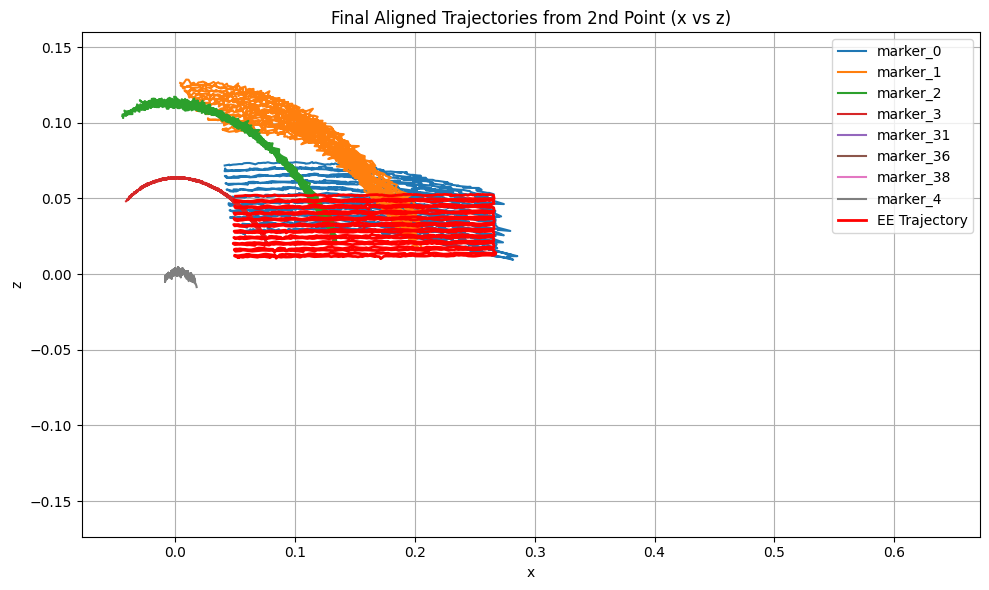

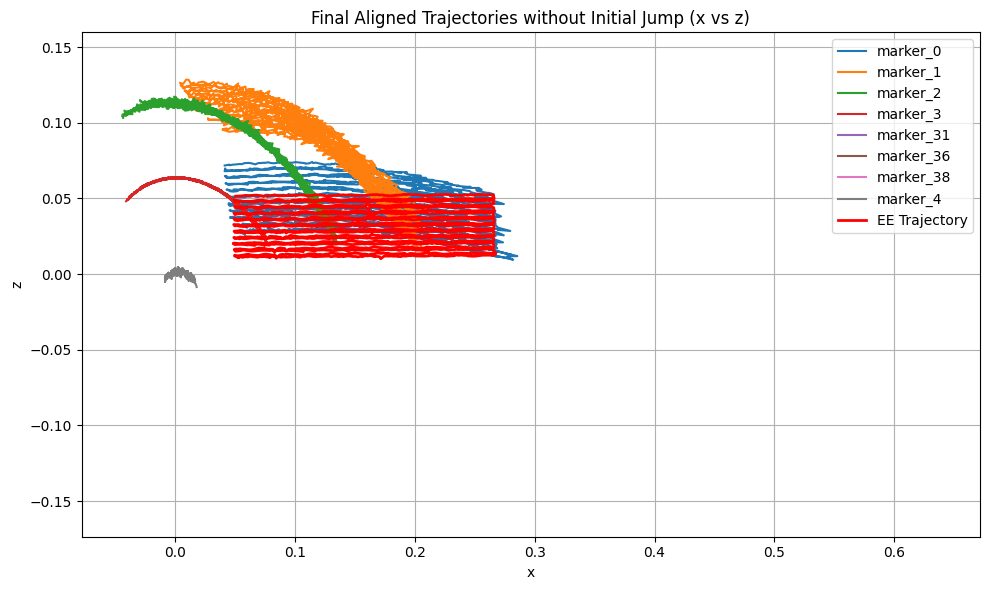

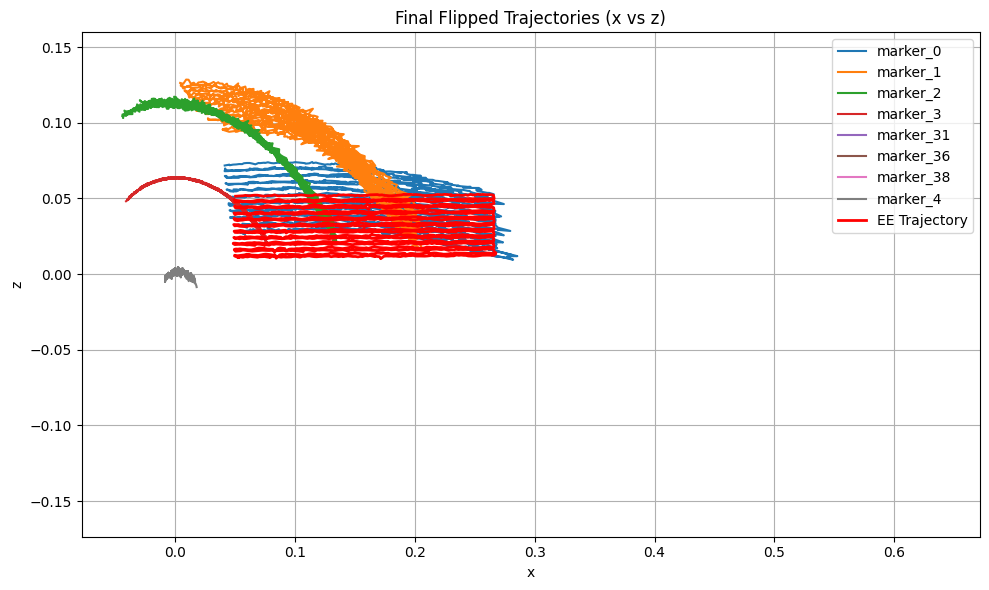

In [8]:
# extract the actual trajectory that starts from [1] data point not 0. 
# plot all the trajectories from second entry to see the actual motion without the initial jump
plt.figure(figsize=(10, 6))
for name in marker_names:
    plt.plot(marker_data_centered[name]["x"][1:], marker_data_centered[name]["z"][1:], label=name)
plt.plot(ee_x[1:], ee_z[1:], label="EE Trajectory", color="red", linewidth=2)
plt.xlabel("x")
plt.ylabel("z")
plt.title("Final Aligned Trajectories from 2nd Point (x vs z)")
plt.legend()
plt.grid(True)
plt.tight_layout()

# remove the first point from all trajectories to remove the initial jump and plot again
for name in marker_names:
    marker_data_centered[name]["x"] = marker_data_centered[name]["x"][1:]
    marker_data_centered[name]["z"] = marker_data_centered[name]["z"][1:]
ee_x = ee_x[1:]
ee_z = ee_z[1:] 

plt.figure(figsize=(10, 6))
for name in marker_names:
    plt.plot(marker_data_centered[name]["x"], marker_data_centered[name]["z"], label=name)
plt.plot(ee_x, ee_z, label="EE Trajectory", color="red", linewidth=2)
plt.xlabel("x")
plt.ylabel("z")
plt.title("Final Aligned Trajectories without Initial Jump (x vs z)")
plt.legend()
plt.grid(True)
plt.tight_layout()

# flip the trajectories, end becomes start and vice versa, to match the expected direction of motion (if needed)
for name in marker_names:
    marker_data_centered[name]["x"] = marker_data_centered[name]["x"][::-1]
    marker_data_centered[name]["z"] = marker_data_centered[name]["z"][::-1]
ee_x = ee_x[::-1]
ee_z = ee_z[::-1]   

# plot the flipped trajectories
plt.figure(figsize=(10, 6))
for name in marker_names:
    plt.plot(marker_data_centered[name]["x"], marker_data_centered[name]["z"], label=name)
plt.plot(ee_x, ee_z, label="EE Trajectory", color="red", linewidth=2)
plt.xlabel("x")
plt.ylabel("z")
plt.title("Final Flipped Trajectories (x vs z)")
plt.legend()
plt.grid(True)
plt.tight_layout()


In [9]:
# we want to store the training data in the required format for directBC.

# we will store the qs as [marker4_x, marker4_y, marker4_z, 0, marker2_x, marker2_y, marker2_z, 0, ee_x, ee_y, ee_z]
# boundary condition is [ee_x, ee_y, ee_z]
# lammbdas can be created using linspace from 0 to 1 with the same length as the trajectories

Loaded 2332 samples
Origin from marker_4 mean:
x0 = 0.0007803438364001456
y0 = 0.06485704630091334
z0 = 0.4803184081603479
Detected chunks:
  traj 0: [0, 110) length=110
  traj 1: [110, 220) length=110
  traj 2: [220, 330) length=110
  traj 3: [330, 440) length=110
  traj 4: [440, 550) length=110
  traj 5: [550, 660) length=110
  traj 6: [660, 770) length=110
  traj 7: [770, 880) length=110
  traj 8: [880, 990) length=110
  traj 9: [990, 1100) length=110
  traj 10: [1100, 1210) length=110
  traj 11: [1210, 1320) length=110
  traj 12: [1320, 1430) length=110
  traj 13: [1430, 1540) length=110
  traj 14: [1540, 1650) length=110
  traj 15: [1650, 1760) length=110
  traj 16: [1760, 1870) length=110
  traj 17: [1870, 1980) length=110
  traj 18: [1980, 2090) length=110
  traj 19: [2090, 2200) length=110
  traj 20: [2200, 2310) length=110
n_traj = 21
train_ids = [0 1]
test_ids  = [2 3]
qs shape = (21, 40, 11)
xb shape = (21, 40, 8)


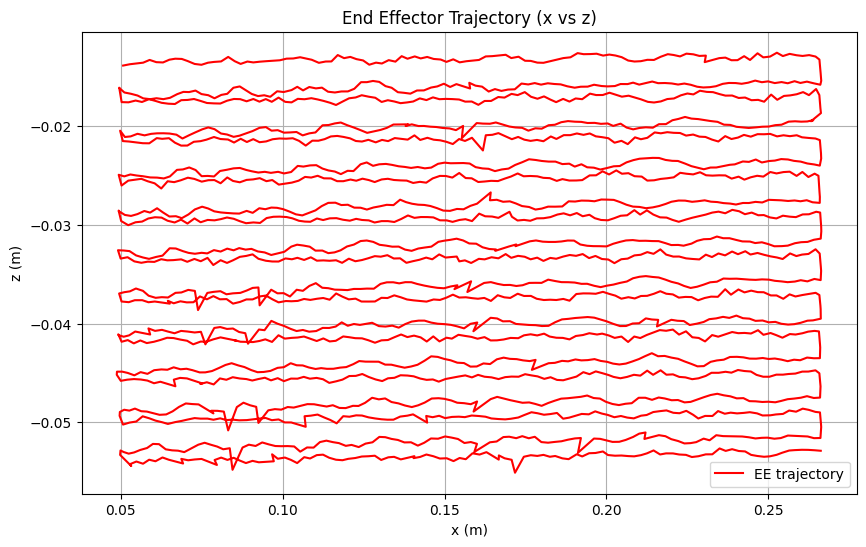

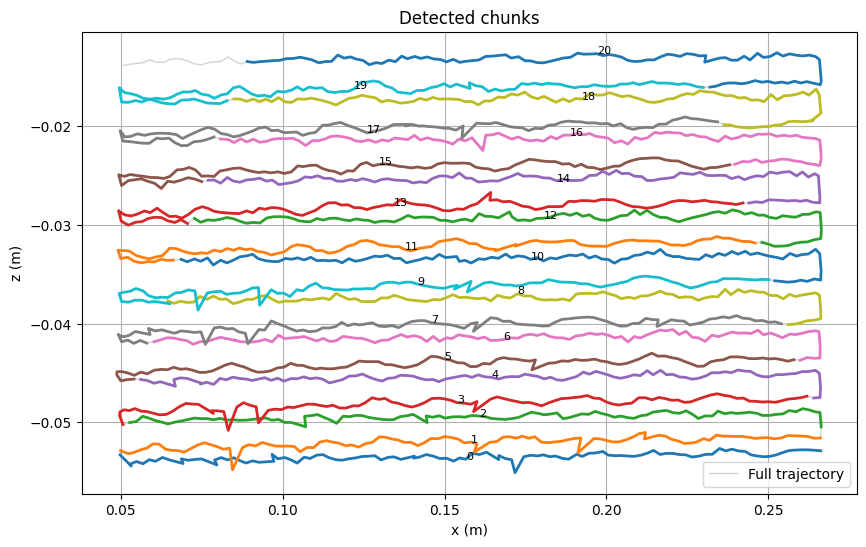

plotting with:
  train_set = [np.int64(0), np.int64(1)]
  test_set  = [np.int64(2), np.int64(3)]


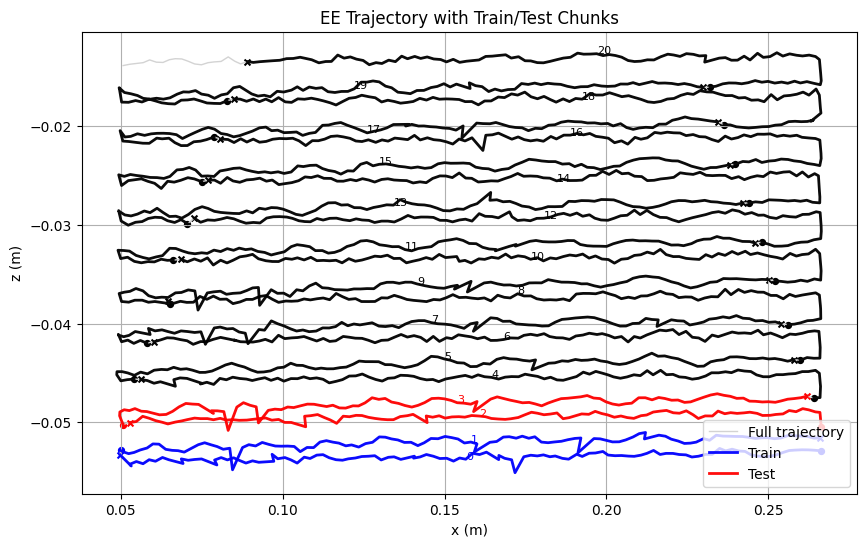

In [10]:
from extract_data_new import extract_multitraj_dataset

result = extract_multitraj_dataset(
        input_json_path=file_path,
        output_all_path="all_chunks.npz",
        output_train_path="train_chunks.npz",
        output_test_path="test_chunks.npz",
        T_common=40,
        plot=True,
        reverse_trajectory=False,
        drop_first = 3,  # drop the first 2 points to remove the initial jump and get a cleaner trajectory
        chunk_len=110,
        stride=110,      # non-overlapping chunks
        drop_last=True,
        train_ids=[0, 1],
        test_ids=[2, 3],
    )

In [11]:
print(result["qs"][0,0,:])

[ 0.          0.          0.          0.          0.13387114  0.
 -0.02298582  0.          0.266166    0.         -0.05289056]
